In [12]:
import pandas as pd
import numpy as np


In [13]:
data = pd.read_csv("Weather-2020-2025.csv")

In [14]:
#Quick look into the data
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52632 entries, 0 to 52631
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   location_id                    52632 non-null  int64  
 1   time                           52632 non-null  object 
 2   temperature_2m                 52632 non-null  float64
 3   relative_humidity_2m (%)       52632 non-null  int64  
 4   wind_speed_10m (km/h)          52632 non-null  float64
 5   precipitation (mm)             52632 non-null  float64
 6   is_day                         52632 non-null  int64  
 7   wind_speed_100m (km/h)         52632 non-null  float64
 8   wind_gusts_10m (km/h)          52632 non-null  float64
 9   wind_direction_100m            52632 non-null  int64  
 10  wind_direction_10m             52632 non-null  int64  
 11  cloud_cover (%)                52632 non-null  int64  
 12  vapour_pressure_deficit (kPa)  52632 non-null 

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20


In [15]:
#Remove null values
data.dropna()


,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52627,2,2025-12-31T19:00,10.4,86,6.1,0.0,0,13.0,11.9,65,45,100,0.17
52628,2,2025-12-31T20:00,10.4,87,5.7,0.0,0,13.1,11.9,77,58,100,0.17
52629,2,2025-12-31T21:00,10.6,87,5.5,0.0,0,13.3,11.2,91,67,100,0.16
52630,2,2025-12-31T22:00,10.5,89,9.0,0.0,0,19.8,16.2,106,91,100,0.14


In [16]:
#Reduce data frame to entries during the daytime (base case)
dayFilter = data[data["is_day"] == 1]
dayFilter

#Convert time to date time
data["time"] = pd.to_datetime(data["time"])
data

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01 00:00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01 01:00:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01 02:00:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01 03:00:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01 04:00:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52627,2,2025-12-31 19:00:00,10.4,86,6.1,0.0,0,13.0,11.9,65,45,100,0.17
52628,2,2025-12-31 20:00:00,10.4,87,5.7,0.0,0,13.1,11.9,77,58,100,0.17
52629,2,2025-12-31 21:00:00,10.6,87,5.5,0.0,0,13.3,11.2,91,67,100,0.16
52630,2,2025-12-31 22:00:00,10.5,89,9.0,0.0,0,19.8,16.2,106,91,100,0.14


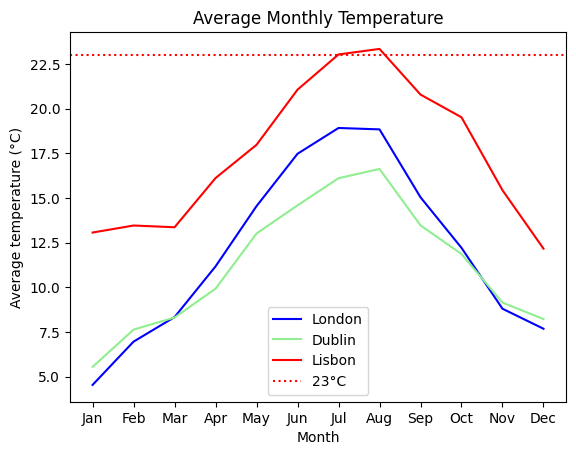

In [17]:
#Graph showing average temperature per month per city
import matplotlib.pyplot as plt
fig = plt.figure()
# get london data
london = data[data['location_id'] == 0].copy()
# Create a field for Month
london["month"] = london["time"].dt.month
# find average temps
lndAvgTemp = london.groupby("month")["temperature_2m"].mean()

# get Dublin data
dublin = data[data['location_id'] == 1].copy()
# Create a field for Month
dublin["month"] = dublin["time"].dt.month
# find average temps
dubAvgTemp = dublin.groupby("month")["temperature_2m"].mean()

#get Lisbon data
lisbon = data[data['location_id'] == 2].copy()
# Create a field for Month
lisbon["month"] = lisbon["time"].dt.month
# find average temps
lisAvgTemp = lisbon.groupby("month")["temperature_2m"].mean()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# plot lines
plt.plot(month_labels, lndAvgTemp, label="London", color = "blue")
plt.plot(month_labels, dubAvgTemp, label="Dublin", color = "lightgreen")
plt.plot(month_labels, lisAvgTemp, label="Lisbon", color = "red")

# threshold
plt.axhline(y=23, color='red', linestyle=':', label="23°C")

# x-axis label
plt.xlabel('Month')

# y-axis label
plt.ylabel('Average temperature (°C)')

# axis title
plt.title('Average Monthly Temperature')

plt.legend()
plt.show()

fig.savefig("average_monthly_temperature.png")

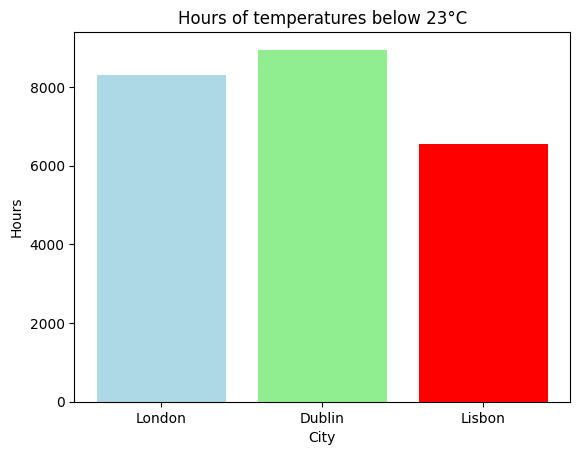

In [18]:
#Hours of time below 23°C during the day
fig = plt.figure()
# get london data
dayData = data[data['is_day'] == 1].copy()
# Create a field for hours
dayData["hour"] = dayData["time"].dt.hour

# Temp below 23 degrees
dayDataTemp = dayData[dayData["temperature_2m"] < 23]

tempSize = dayDataTemp.groupby("location_id")["temperature_2m"].size()

city_labels = ["London", "Dublin", "Lisbon"]
colours = ["lightblue","lightgreen","red"]

plt.bar(city_labels, tempSize, color = colours)

# x-axis label
plt.xlabel('City')

# y-axis label
plt.ylabel('Hours')

# axis title
plt.title('Hours of temperatures below 23°C')

plt.show()

fig.savefig("hourly_temp_below_23.png")



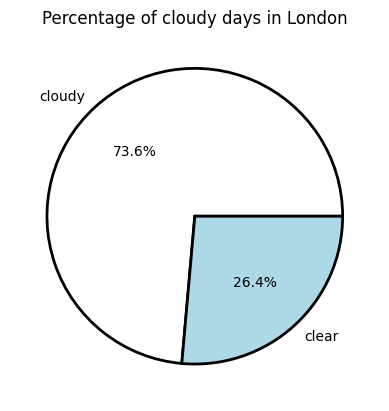

In [19]:
#Pie chart for clear and cloudy days
fig = plt.figure()
data["date"] = data["time"].dt.date

#Get data for each city
london = data[data["location_id"] == 0].copy()
dublin = data[data["location_id"] == 1].copy()
lisbon = data[data["location_id"] == 2].copy()

def generate_cloudy_pie(city, cityName):
    daily_means = city.groupby("date")["cloud_cover (%)"].mean()
    total_days = len(daily_means)
    cloudy_days = len(daily_means[daily_means > 50])

    percentage_cloudy = (cloudy_days/total_days)*100
    percentage_clear = 100 - percentage_cloudy

    labels = ["cloudy","clear"]
    colours = ["white","lightblue"]

    plt.pie([percentage_cloudy, percentage_clear], labels=labels, autopct='%1.1f%%', colors = colours, wedgeprops = {"edgecolor" : "black",'linewidth': 2,'antialiased': True})

    plt.title(f"Percentage of cloudy days in {cityName}")
    plt.show()

generate_cloudy_pie(london,"London")
fig.savefig("cloudy_days_london_pie.png")

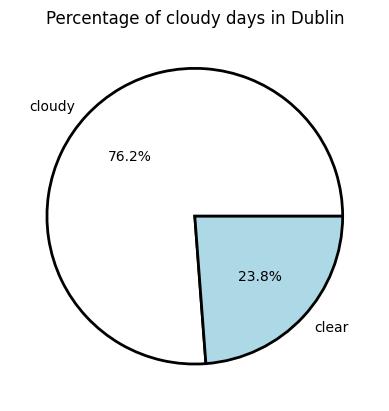

In [20]:
fig = plt.figure()
generate_cloudy_pie(dublin,"Dublin")
fig.savefig("cloudy_days_dublin_pie.png")

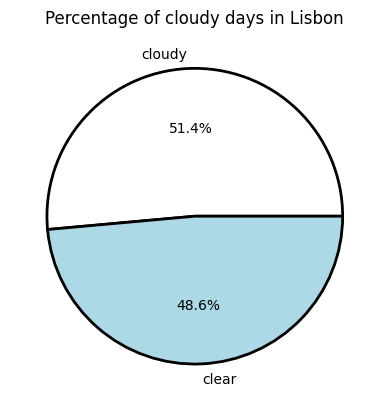

In [21]:
fig = plt.figure()
generate_cloudy_pie(lisbon,"Lisbon")
fig.savefig("cloudy_days_lisbon_pie.png")